# Exploratory Data Analysis — Retail Sales in Istanbul
**Oasis Infobyte Internship · Data Analytics · Level 1 — Task 1**<br>
**Author:** Ojewumi Asaph Felix

**Objective:** explore a retail sales dataset to uncover sales patterns, customer behaviour and product performance, and turn them into actionable business recommendations.

**Dataset:** *Customer Shopping Dataset — Retail Sales Data* (Kaggle) — 99,457 purchases made in **10 shopping malls in Istanbul**, from January 2021 to March 2023. Amounts are in Turkish lira (TRY).

> **Key findings**
> - **Clothing, Shoes and Technology generate 95 % of revenue** with only 50 % of the purchases.
> - The average basket is **the same everywhere (≈ 690 TRY)**, whatever the mall, gender or age: differences in revenue come from the **number of visits**, not from spending per visit.
> - Sales are **very stable** (≈ 2.6 M TRY per month) with no strong seasonality; February is lower only because it has fewer days.
> - **60 % of customers are women**, in every category.

**Contents**
1. Data loading and inspection
2. Descriptive statistics
3. Time series analysis
4. Customer demographics
5. Product analysis
6. Correlation analysis
7. Additional insight: where the revenue really comes from
8. Conclusion and business recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Chart style: one hue for magnitudes, a second hue only to compare two series, grey for context
BLUE, ORANGE, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#b9b8b3", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfcecb", "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 12.5, "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe8", "grid.linewidth": 0.8, "axes.axisbelow": True,
})
millions = mtick.FuncFormatter(lambda x, _: f"{x / 1e6:,.1f} M")

## 1. Data Loading and Inspection

In [2]:
df = pd.read_csv("data/customer_shopping_data.csv")
print("Shape:", df.shape)
df.head()

Shape: (99457, 10)


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,"1,500.40",Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,"1,800.51",Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,"3,000.85",Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


In [4]:
print("Missing values           :", df.isna().sum().sum())
print("Duplicated rows          :", df.duplicated().sum())
print("Duplicated invoice numbers:", df["invoice_no"].duplicated().sum())
print("Unique customers         :", df["customer_id"].nunique(), "for", len(df), "invoices")

Missing values           : 0
Duplicated rows          : 0
Duplicated invoice numbers: 0
Unique customers         : 99457 for 99457 invoices


**Observations:**
- **99,457 rows, 10 columns**, with **no missing values and no duplicates**: the dataset is clean.
- Each customer appears **only once**, so one row = one customer = one purchase. We can therefore study customers directly at the transaction level (but we cannot study repeat purchases).
- `invoice_date` is stored as text and must be converted to a date.

### 1.1 What does the `price` column really contain?
Before computing any revenue, we must check whether `price` is the **unit price** or the **total price of the line**.

In [5]:
unit_price = (df["price"] / df["quantity"]).round(2)
unit_price.groupby(df["category"]).agg(["min", "max", "nunique"])

,min,max,nunique
category,,,
Books,15.15,15.15,1
Clothing,300.08,300.08,1
Cosmetics,40.66,40.66,1
Food & Beverage,5.23,5.23,1
Shoes,600.17,600.17,1
Souvenir,11.73,11.73,1
Technology,"1,050.00","1,050.00",1
Toys,35.84,35.84,1


**Important finding:** `price / quantity` gives **exactly one value per category** (e.g. 300.08 for Clothing). So:
- each category has a fixed **unit price**, and
- `price` is already the **total amount of the line** (unit price × quantity).

👉 Revenue is therefore `price`, **not** `price × quantity`. Multiplying again would inflate revenue by up to **5×** — a mistake that is easy to make with this dataset.

### 1.2 Data preparation

In [6]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], format="%d/%m/%Y")
df = df.rename(columns={"price": "revenue"})
df["unit_price"] = unit_price
df["month"] = df["invoice_date"].dt.to_period("M")
df["quarter"] = df["invoice_date"].dt.to_period("Q")
df["weekday"] = df["invoice_date"].dt.day_name()
df["age_group"] = pd.cut(df["age"], bins=[17, 24, 34, 44, 54, 64, 69],
                         labels=["18–24", "25–34", "35–44", "45–54", "55–64", "65–69"])
for col in ["gender", "category", "payment_method", "shopping_mall"]:
    df[col] = df[col].astype("category")

print("Period covered:", df["invoice_date"].min().date(), "→", df["invoice_date"].max().date())
print("Transactions in March 2023:", (df["month"] == "2023-03").sum())

Period covered: 2021-01-01 → 2023-03-08
Transactions in March 2023: 970


**Note:** the data stops on **8 March 2023**, so March 2023 is an incomplete month. It is **excluded from the time-series charts** to avoid showing a fake drop in sales.

## 2. Descriptive Statistics
Mean, median, mode and standard deviation of every numerical column.

In [7]:
num_cols = ["age", "quantity", "unit_price", "revenue"]
desc = pd.DataFrame({
    "mean": df[num_cols].mean(),
    "median": df[num_cols].median(),
    "mode": df[num_cols].mode().iloc[0],
    "std": df[num_cols].std(),
    "min": df[num_cols].min(),
    "max": df[num_cols].max(),
})
desc

,mean,median,mode,std,min,max
age,43.43,43.00,37.00,14.99,18.00,69.00
quantity,3.00,3.00,3.00,1.41,1.00,5.00
unit_price,229.28,40.66,300.08,266.05,5.23,"1,050.00"
revenue,689.26,203.30,600.16,941.18,5.23,"5,250.00"


In [8]:
print(f"Total revenue       : {df['revenue'].sum():,.0f} TRY")
print(f"Average basket      : {df['revenue'].mean():,.0f} TRY")
print(f"Median basket       : {df['revenue'].median():,.0f} TRY")
print(f"Items sold          : {df['quantity'].sum():,}")

Total revenue       : 68,551,366 TRY
Average basket      : 689 TRY
Median basket       : 203 TRY
Items sold          : 298,712


**Observations:**
- Customers are between **18 and 69 years old** (mean ≈ 43), and buy **1 to 5 items** per purchase (mean = 3).
- The **mean basket (≈ 689 TRY) is more than 3× the median (≈ 203 TRY)**: the revenue distribution is strongly **right-skewed**. A few expensive purchases (Technology, Shoes, Clothing) pull the mean up, so the **median** better represents a "typical" purchase.
- The standard deviation of revenue (≈ 941 TRY) is larger than its mean, which confirms very unequal purchase values.

## 3. Time Series Analysis
### 3.1 Monthly sales

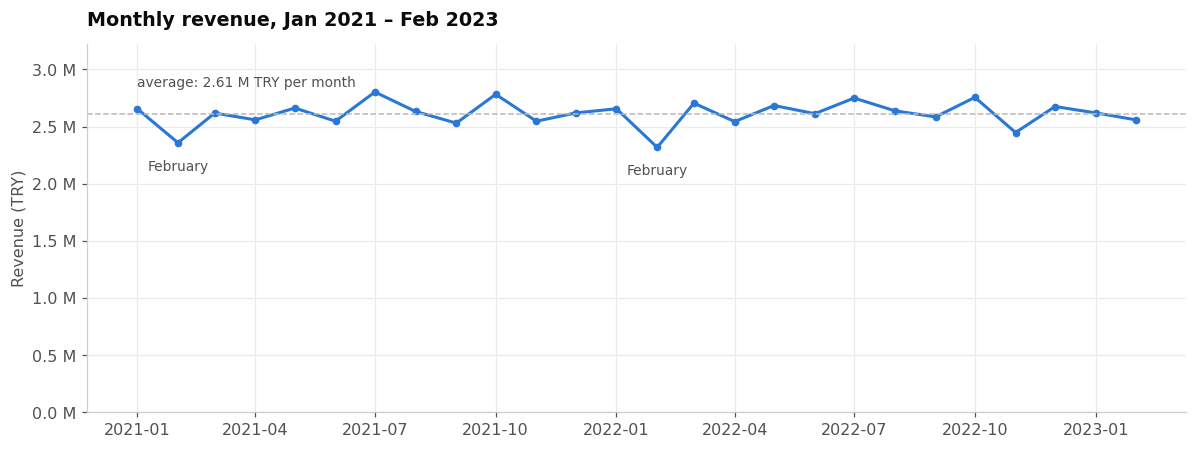

In [9]:
full = df[df["month"] < pd.Period("2023-03", "M")]          # complete months only
monthly = full.groupby("month")["revenue"].sum()

fig, ax = plt.subplots(figsize=(11, 4.2))
x = monthly.index.to_timestamp()
ax.plot(x, monthly.values, color=BLUE, lw=2, marker="o", ms=4)
ax.axhline(monthly.mean(), color=GREY, ls="--", lw=1)
ax.text(x[0], monthly.mean() * 1.09, f"average: {monthly.mean() / 1e6:.2f} M TRY per month", color=MUTED, fontsize=9)
for d in [pd.Timestamp("2021-02-01"), pd.Timestamp("2022-02-01")]:
    ax.annotate("February", (d, monthly[d.to_period("M")]), xytext=(0, -18),
                textcoords="offset points", ha="center", color=MUTED, fontsize=9)
ax.yaxis.set_major_formatter(millions)
ax.set_ylim(0, monthly.max() * 1.15)
ax.set_ylabel("Revenue (TRY)")
ax.set_title("Monthly revenue, Jan 2021 – Feb 2023")
plt.tight_layout()
plt.savefig("images/monthly_revenue.png")
plt.show()

In [10]:
per_day = (monthly / monthly.index.days_in_month).rename("revenue per day")
pd.DataFrame({"revenue": monthly, "days": monthly.index.days_in_month, "revenue per day": per_day}).loc[
    ["2021-01", "2021-02", "2021-03", "2022-01", "2022-02", "2022-03"]]

,revenue,days,revenue per day
month,,,
2021-01,"2,656,422.78",31,"85,691.06"
2021-02,"2,358,636.34",28,"84,237.01"
2021-03,"2,618,434.14",31,"84,465.62"
2022-01,"2,656,149.96",31,"85,682.26"
2022-02,"2,318,201.08",28,"82,792.90"
2022-03,"2,705,190.76",31,"87,264.22"


**Observations:**
- Revenue is **remarkably stable**: between 2.3 and 2.8 M TRY every month, with no growth and no decline over two years.
- The only visible dips are in **February**. But revenue **per day** in February is the same as in January or March: the dip is simply because **February has 28 days**, not because customers buy less.
- There is **no strong seasonality** (no year-end peak for example), which is unusual for retail and worth keeping in mind.

### 3.2 Quarterly sales

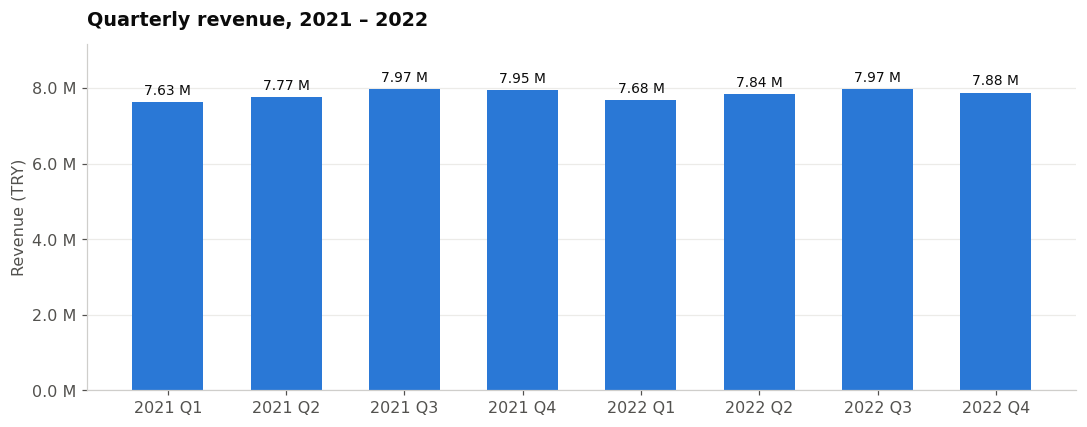

In [11]:
quarterly = full.groupby("quarter")["revenue"].sum()
quarterly = quarterly[quarterly.index < pd.Period("2023Q1", "Q")]      # 2023 Q1 is incomplete

fig, ax = plt.subplots(figsize=(10, 4))
labels = [str(q).replace("Q", " Q") for q in quarterly.index]
bars = ax.bar(labels, quarterly.values, color=BLUE, width=0.6)
ax.bar_label(bars, labels=[f"{v / 1e6:.2f} M" for v in quarterly.values], padding=3, color=INK, fontsize=9)
ax.yaxis.set_major_formatter(millions)
ax.set_ylim(0, quarterly.max() * 1.15)
ax.set_ylabel("Revenue (TRY)")
ax.set_title("Quarterly revenue, 2021 – 2022")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("images/quarterly_revenue.png")
plt.show()

**Observation:** every quarter brings between **7.6 and 8.0 M TRY**. **Q3 (July–September) is slightly the strongest** in both years and Q1 the weakest (because of February), but the gap is only about 4 %.

## 4. Customer Demographics
### 4.1 Age distribution

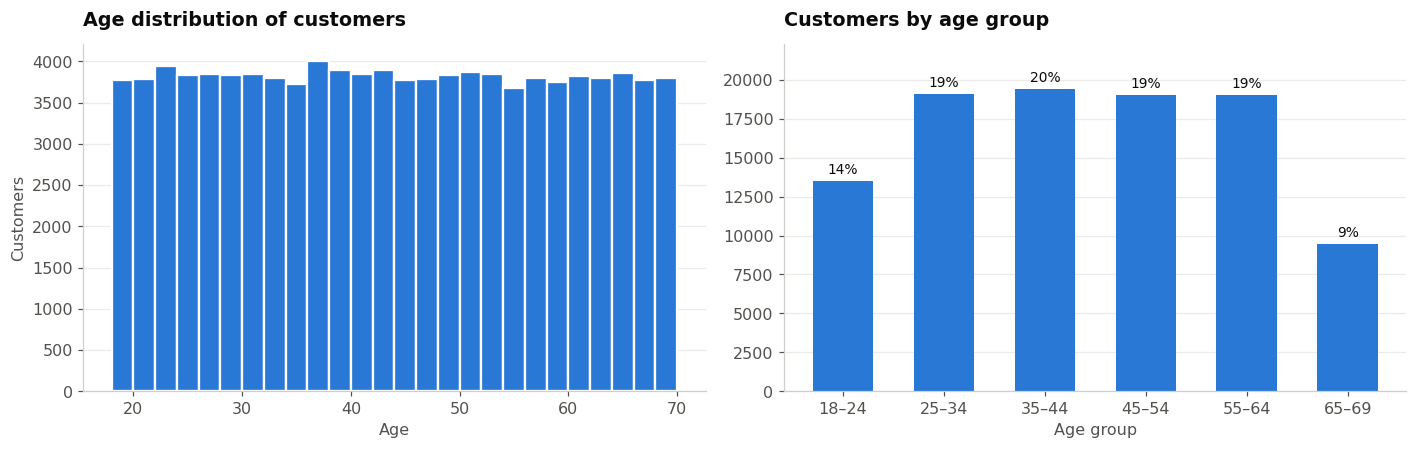

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(df["age"], bins=range(18, 71, 2), color=BLUE, edgecolor="white", linewidth=1.5)
axes[0].set_title("Age distribution of customers")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Customers")
axes[0].grid(axis="x", visible=False)

groups = df["age_group"].value_counts().sort_index()
bars = axes[1].bar(groups.index.astype(str), groups.values, color=BLUE, width=0.6)
axes[1].bar_label(bars, labels=[f"{v / len(df):.0%}" for v in groups.values], padding=3, color=INK, fontsize=9)
axes[1].set_title("Customers by age group")
axes[1].set_xlabel("Age group")
axes[1].set_ylim(0, groups.max() * 1.15)
axes[1].grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("images/age_distribution.png")
plt.show()

**Observations:**
- Customers are spread **almost uniformly** between 18 and 69 years old: there is no dominant age.
- The 25–34, 35–44, 45–54 and 55–64 groups each represent about **19 %** of customers. The 18–24 and 65–69 groups are smaller only because they cover fewer years.

### 4.2 Gender breakdown

In [13]:
gender = df.groupby("gender", observed=True).agg(customers=("customer_id", "size"),
                                                 revenue=("revenue", "sum"),
                                                 avg_basket=("revenue", "mean"))
gender["share of customers"] = gender["customers"] / gender["customers"].sum()
gender["share of revenue"] = gender["revenue"] / gender["revenue"].sum()
gender

,customers,revenue,avg_basket,share of customers,share of revenue
gender,,,,,
Female,59482,"40,931,801.62",688.14,0.60,0.60
Male,39975,"27,619,564.29",690.92,0.40,0.40


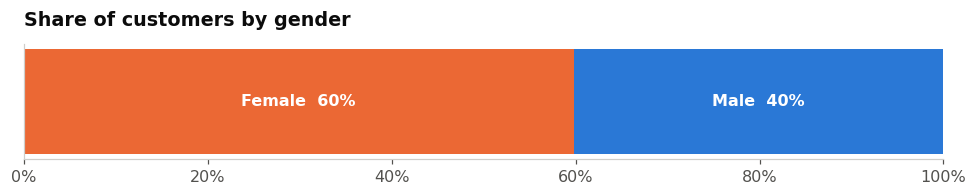

In [14]:
fig, ax = plt.subplots(figsize=(9, 1.9))
share = gender["share of customers"]
ax.barh([0], [share["Female"]], color=ORANGE, height=0.42)
ax.barh([0], [share["Male"]], left=[share["Female"]], color=BLUE, height=0.42)
ax.text(share["Female"] / 2, 0, f"Female  {share['Female']:.0%}", ha="center", va="center", color="white", fontweight="bold")
ax.text(share["Female"] + share["Male"] / 2, 0, f"Male  {share['Male']:.0%}", ha="center", va="center", color="white", fontweight="bold")
ax.set_xlim(0, 1)
ax.set_yticks([])
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_title("Share of customers by gender")
ax.grid(False)
plt.tight_layout()
plt.savefig("images/gender_split.png")
plt.show()

In [15]:
basket = pd.DataFrame({
    "by gender": df.groupby("gender", observed=True)["revenue"].mean(),
}).T
basket_age = df.groupby("age_group", observed=True)["revenue"].mean().rename("average basket (TRY)")
display(basket.round(0))
basket_age.to_frame().T.round(0)

gender,Female,Male
by gender,688.00,691.00


age_group,18–24,25–34,35–44,45–54,55–64,65–69
average basket (TRY),679.00,686.00,700.00,693.00,685.00,689.00


**Observations:**
- **Women represent 60 % of customers** and 60 % of revenue.
- The **average basket is almost identical** for women (688 TRY) and men (691 TRY), and across all age groups (679 to 700 TRY).
- So women generate more revenue **because they are more numerous, not because they spend more per purchase**.

## 5. Product Analysis
The dataset does not contain individual product names, only **8 product categories**. We therefore rank the **categories** (by units sold and by revenue), and add the ranking of the **10 shopping malls** as a "top 10".

In [16]:
cat = df.groupby("category", observed=True).agg(transactions=("invoice_no", "size"),
                                               units_sold=("quantity", "sum"),
                                               revenue=("revenue", "sum"),
                                               unit_price=("unit_price", "first"))
cat["share of revenue"] = cat["revenue"] / cat["revenue"].sum()
cat.sort_values("units_sold", ascending=False)

,transactions,units_sold,revenue,unit_price,share of revenue
category,,,,,
Clothing,34487,103558,"31,075,684.64",300.08,0.45
Cosmetics,15097,45465,"1,848,606.90",40.66,0.03
Food & Beverage,14776,44277,"231,568.71",5.23,0.00
Toys,10087,30321,"1,086,704.64",35.84,0.02
Shoes,10034,30217,"18,135,336.89",600.17,0.26
Technology,4996,15021,"15,772,050.00","1,050.00",0.23
Books,4981,14982,"226,977.30",15.15,0.00
Souvenir,4999,14871,"174,436.83",11.73,0.00


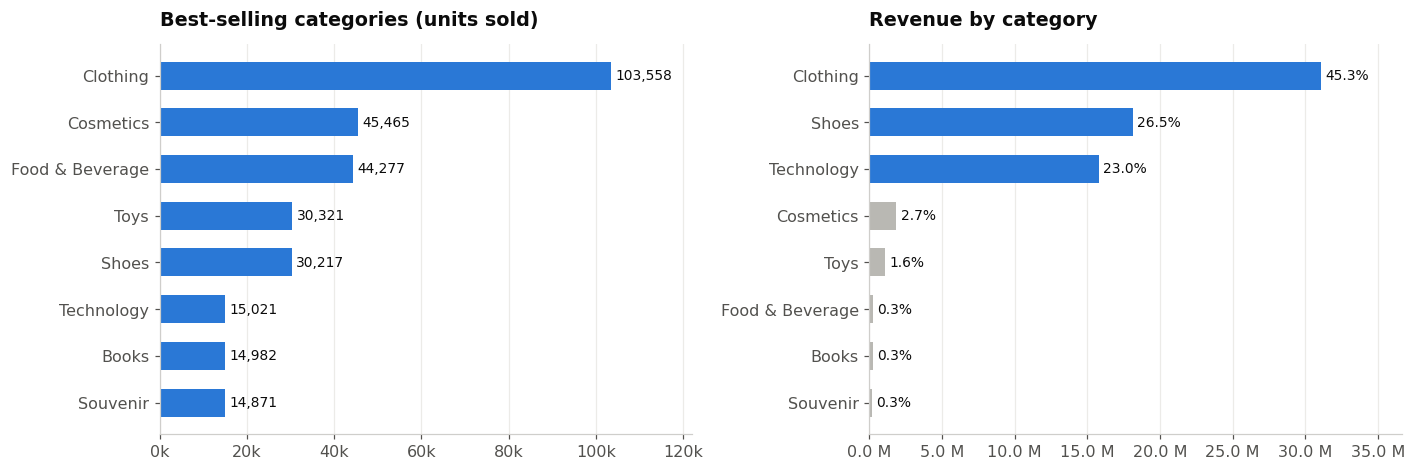

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

units = cat["units_sold"].sort_values()
b = axes[0].barh(units.index.astype(str), units.values, color=BLUE, height=0.6)
axes[0].bar_label(b, labels=[f"{v:,.0f}" for v in units.values], padding=3, color=INK, fontsize=9)
axes[0].set_title("Best-selling categories (units sold)")
axes[0].set_xlim(0, units.max() * 1.18)
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))
axes[0].grid(axis="y", visible=False)

rev = cat["revenue"].sort_values()
colors = [BLUE if v > 0.1 * rev.sum() else GREY for v in rev.values]
b = axes[1].barh(rev.index.astype(str), rev.values, color=colors, height=0.6)
axes[1].bar_label(b, labels=[f"{v / rev.sum():.1%}" for v in rev.values], padding=3, color=INK, fontsize=9)
axes[1].set_title("Revenue by category")
axes[1].set_xlim(0, rev.max() * 1.18)
axes[1].xaxis.set_major_formatter(millions)
axes[1].grid(axis="y", visible=False)

plt.tight_layout()
plt.savefig("images/categories.png")
plt.show()

**Observations:**
- **Clothing is the clear leader** in both units sold (≈ 104k items) and revenue (**45 %** of total revenue).
- The two rankings are **very different**: Cosmetics and Food & Beverage are the 2nd and 3rd best-selling categories in units, but together they bring only **3 %** of revenue, because their unit prices are low (41 and 5 TRY).
- On the other hand, **Technology** is among the least sold categories (15k units) but brings **23 %** of revenue thanks to a unit price of 1,050 TRY.

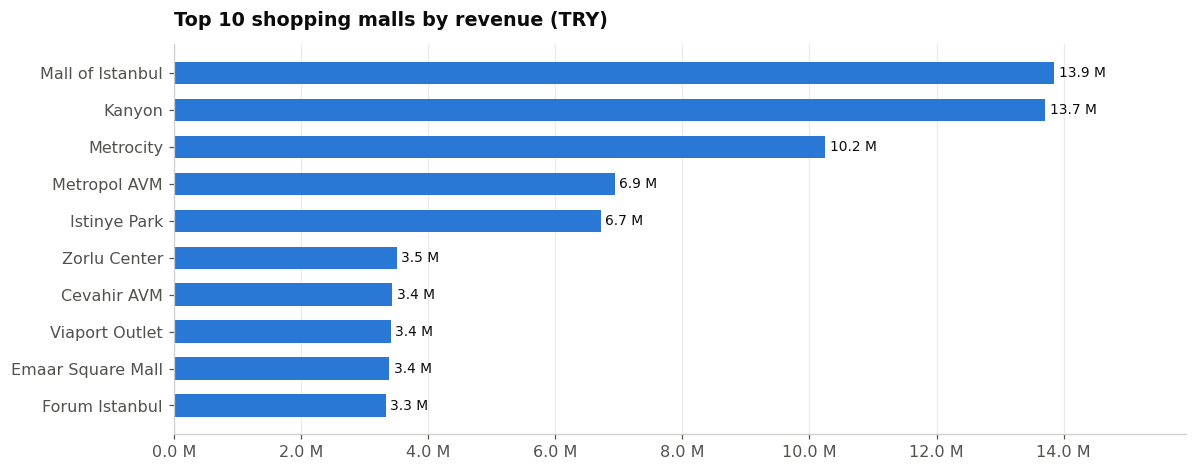

,transactions,revenue,avg_basket
shopping_mall,,,
Mall of Istanbul,19943,"13,851,737.62",694.57
Kanyon,19823,"13,710,755.24",691.66
Metrocity,15011,"10,249,980.07",682.83
Metropol AVM,10161,"6,937,992.99",682.81
Istinye Park,9781,"6,717,077.54",686.75
Zorlu Center,5075,"3,509,649.02",691.56
Cevahir AVM,4991,"3,433,671.84",687.97
Viaport Outlet,4914,"3,414,019.46",694.75
Emaar Square Mall,4811,"3,390,408.31",704.72


In [18]:
malls = df.groupby("shopping_mall", observed=True).agg(transactions=("invoice_no", "size"),
                                                      revenue=("revenue", "sum"),
                                                      avg_basket=("revenue", "mean"))
malls = malls.sort_values("revenue", ascending=False)

fig, ax = plt.subplots(figsize=(11, 4.4))
r = malls["revenue"].sort_values()
b = ax.barh(r.index.astype(str), r.values, color=BLUE, height=0.6)
ax.bar_label(b, labels=[f"{v / 1e6:.1f} M" for v in r.values], padding=3, color=INK, fontsize=9)
ax.set_xlim(0, r.max() * 1.15)
ax.xaxis.set_major_formatter(millions)
ax.set_title("Top 10 shopping malls by revenue (TRY)")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("images/top_malls.png")
plt.show()
malls

**Observations:**
- **Mall of Istanbul, Kanyon and Metrocity** generate **55 %** of total revenue.
- The average basket is **almost identical in every mall** (674 to 705 TRY). The revenue gap between malls comes **entirely from the number of transactions** (footfall): Mall of Istanbul has 4× more purchases than Forum Istanbul.

## 6. Correlation Analysis

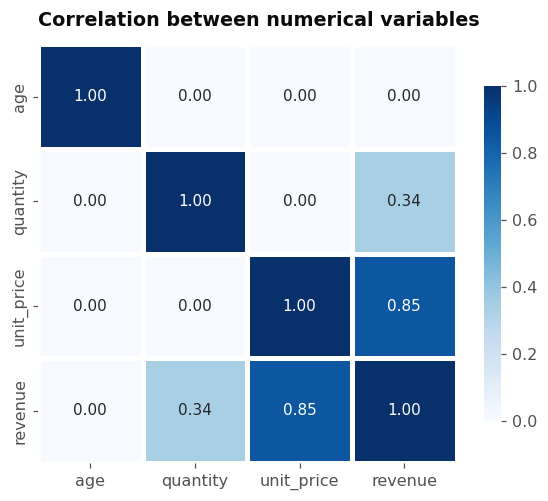

In [19]:
corr = df[["age", "quantity", "unit_price", "revenue"]].corr().round(2) + 0.0     # + 0.0 removes "-0.00"

fig, ax = plt.subplots(figsize=(5.6, 4.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True,
            linewidths=2, linecolor="white", cbar_kws={"shrink": 0.8}, ax=ax,
            annot_kws={"fontsize": 10})
ax.set_title("Correlation between numerical variables")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("images/correlation_heatmap.png")
plt.show()

**Observations:**
- **Revenue is driven by the unit price** (r = 0.85), i.e. by the **category** bought, much more than by quantity (r = 0.34).
- **Age is not correlated with anything** (r ≈ 0): older and younger customers buy the same quantities and spend the same amounts.
- Quantity and unit price are independent (r ≈ 0): customers do not buy fewer items when the product is more expensive.

## 7. Additional Insight: Where the Revenue Really Comes From
Comparing each category's **share of purchases** with its **share of revenue** reveals a strong imbalance that the previous charts only suggested.

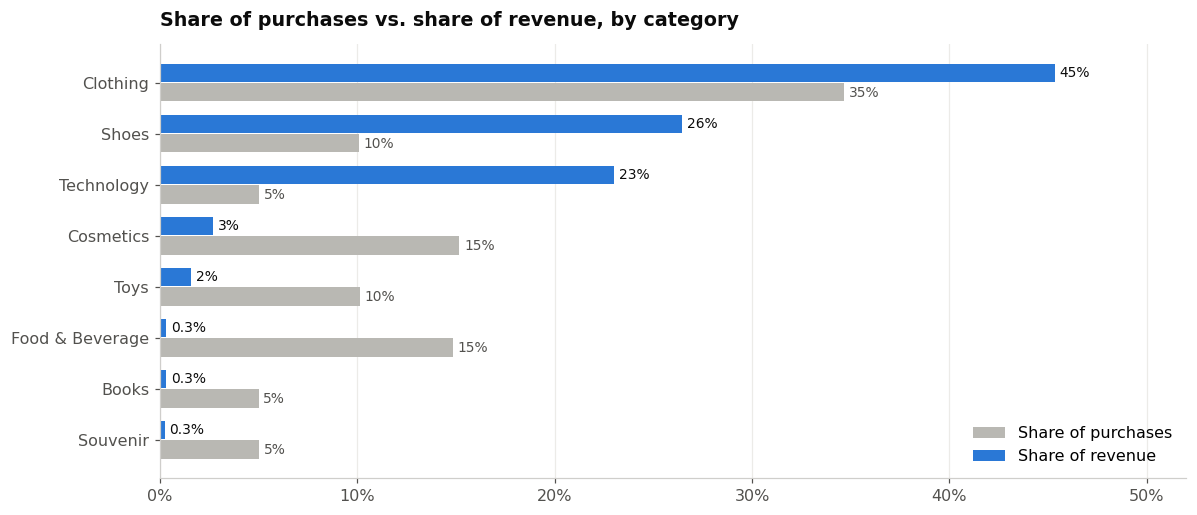

In [20]:
comp = pd.DataFrame({
    "Share of purchases": cat["transactions"] / cat["transactions"].sum(),
    "Share of revenue": cat["share of revenue"],
}).sort_values("Share of revenue")

fig, ax = plt.subplots(figsize=(11, 4.8))
y = np.arange(len(comp))
h = 0.36
b1 = ax.barh(y - h / 2 - 0.01, comp["Share of purchases"], height=h, color=GREY, label="Share of purchases")
b2 = ax.barh(y + h / 2 + 0.01, comp["Share of revenue"], height=h, color=BLUE, label="Share of revenue")
ax.bar_label(b2, labels=[f"{v:.0%}" if v >= 0.01 else f"{v:.1%}" for v in comp["Share of revenue"]], padding=3, color=INK, fontsize=9)
ax.bar_label(b1, labels=[f"{v:.0%}" for v in comp["Share of purchases"]], padding=3, color=MUTED, fontsize=9)
ax.set_yticks(y, comp.index.astype(str))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.set_xlim(0, 0.52)
ax.legend(loc="lower right", frameon=False)
ax.set_title("Share of purchases vs. share of revenue, by category")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("images/purchases_vs_revenue.png")
plt.show()

In [21]:
top3 = ["Clothing", "Shoes", "Technology"]
low4 = ["Food & Beverage", "Books", "Souvenir", "Toys"]
print(f"Clothing + Shoes + Technology : {comp.loc[top3, 'Share of purchases'].sum():.0%} of purchases → {comp.loc[top3, 'Share of revenue'].sum():.0%} of revenue")
print(f"Food, Books, Souvenir, Toys   : {comp.loc[low4, 'Share of purchases'].sum():.0%} of purchases → {comp.loc[low4, 'Share of revenue'].sum():.1%} of revenue")

Clothing + Shoes + Technology : 50% of purchases → 95% of revenue
Food, Books, Souvenir, Toys   : 35% of purchases → 2.5% of revenue


**Non-obvious insight:**
- **Half of the purchases (Clothing, Shoes, Technology) generate 95 % of the revenue.**
- In contrast, Food & Beverage, Books, Souvenirs and Toys represent **35 % of purchases but less than 3 % of revenue**.
- These low-value categories are not useless: they bring **a lot of visits**. Since revenue per mall depends on footfall (section 5), they can be used as a **traffic driver** to bring customers who may also buy clothes or shoes.

## 8. Conclusion and Business Recommendations

**Summary of findings**
- Sales are **stable over time** (≈ 2.6 M TRY per month), without real seasonality.
- The customer base is **60 % female**, spread evenly across all ages, and the **average basket is the same for every segment**.
- **3 categories out of 8 make 95 % of the revenue**, and **3 malls out of 10 make 55 %** of it.

**Recommendations**
1. **Protect the three revenue engines — Clothing, Shoes and Technology.** Prioritise their stock availability, shelf space and promotions. For Technology (the highest basket at up to 5,250 TRY), offer **instalment payments or extended warranties**: credit cards are already used in 35 % of purchases.
2. **Use low-value categories to increase the basket.** Food & Beverage, Cosmetics and Toys are bought very often but bring little revenue. **Bundles and cross-selling** (e.g. "buy shoes, get 20 % off cosmetics") can turn these frequent visits into higher-value purchases.
3. **Grow footfall in the smaller malls instead of trying to raise spending per visit.** Since the average basket is already the same everywhere, the 5 smallest malls (≈ 3.4 M TRY each) will only grow by attracting **more visitors**: local events, loyalty programmes and targeted campaigns.
4. **Target women in marketing campaigns, without neglecting any age group.** Women are 60 % of customers in every category, while age has no effect on spending: campaigns should be segmented by **gender and category**, not by age.

**Limitations**
- The dataset contains **categories, not individual products**, so a real "top 10 products" cannot be computed.
- Each customer appears only once: **loyalty and repeat purchases cannot be analysed**.
- The distributions (ages, quantities, sales per month) are unusually uniform, which suggests the data may be **partly simulated**. The conclusions should be confirmed on real transaction data.